## Model Variant
Let's try a CMR variant that modifies retrieve to better 

In [1]:
from jaxcmr.memorysearch import CMR, retrieve, _retrieve_item
from jaxcmr.memory import InstanceMcf, LinearAssociativeMfc
from jaxcmr.context import TemporalContext
from jax import numpy as jnp, jit
from functools import partial

class TestModel(CMR, mutable=True):
    pass

@partial(jit, static_argnums=(0, 1, 2, 3, 4))
def basic_init_test(
    mfc_init,
    mcf_init,
    context_init,
    item_count,
    presentation_count,
    parameters: dict,
) -> TestModel:
    """Initialize CMR with linear associative memories and a temporal context."""

    mfc = mfc_init(item_count, presentation_count, parameters)
    mcf = mcf_init(item_count, presentation_count, parameters)
    context = context_init(item_count)
    items = jnp.eye(item_count, item_count)
    return TestModel(items, presentation_count, context, mfc, mcf, parameters)

def TestCMR(
    item_count,
    presentation_count,
    parameters: dict,
) -> TestModel:
    
    return basic_init_test(
        LinearAssociativeMfc.create,
        InstanceMcf.create,
        TemporalContext.create,
        item_count,
        presentation_count,
        parameters,
    )

In [2]:
from jaxcmr.helpers import ScalarInteger, replace
from jaxcmr.memorysearch import MemorySearch
from jaxcmr.memory import probe
from jaxcmr.context import integrate

@jit
@_retrieve_item.dispatch
def _retrieve_item(model: TestModel, choice: ScalarInteger) -> CMR:
    """Retrieve item with index choice-1"""
    context_input = probe(model.mfc, model.items[choice - 1])
    return replace(
        model,
        context=integrate(model.context, context_input, model.recall_drift_rate),
        recall_sequence=model.recall_sequence.at[model.recall_total].set(choice - 1),
        recall_mask=model.recall_mask.at[choice - 1].set(False),
        recall_total=model.recall_total + 1,
    )

## Data Simulation

In [3]:
from jaxcmr.memorysearch import BaseCMR, InstanceCMR, simulate_h5_from_h5
from jaxcmr.parameters import Parameters, parameter_list
from jaxcmr.analyses import plot_crp, plot_pfr, plot_spc
from jaxcmr.datasets import load_data, generate_trial_mask
import matplotlib.pyplot as plt
import hdf5storage
import os
import json
import jax


model_name = 'Base_CMR'
data_tag = 'LohnasKahana2014'
trial_query = "data['list_type'] != -1"

analyses = {'CRP': plot_crp, 'PFR': plot_pfr, 'SPC': plot_spc}

# figures_path = "icmr/{}_{}_{}_{}.pdf"
simulation_path = 'D:/data/results/{}_{}_{}.h5'
param_path = 'D:/data/results/{}_{}_{}.jsonl'
data_path = 'D:/data/{}.h5'
    
ignore_first_recall = False
data = load_data(data_path.format(data_tag))
# param_list = parameter_list(param_path.format(model_name, data_tag, ignore_first_recall))

with open(param_path.format(model_name, data_tag, ignore_first_recall)) as f:
    param_list = [json.loads(line) for line in f.readlines()]

with jax.disable_jit():
    result = simulate_h5_from_h5(
        TestCMR, #Instance_CMR, #Base_CMR, # a free recall model
        data, # data in EMBAM format 
        param_list, #parameters.fixed, # parameters for model initialization
        jax.random.PRNGKey(0),
        generate_trial_mask(data, trial_query), # mask to filter data with before simulation 
        1, # number of simulations to run
    )

sim_h5_path = simulation_path.format(data_tag, model_name, ignore_first_recall)

# hdf5storage.write(data=result, path='/data', filename=sim_h5_path, matlab_compatible=True, store_python_metadata=True)

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


## Generic Summary Statistics

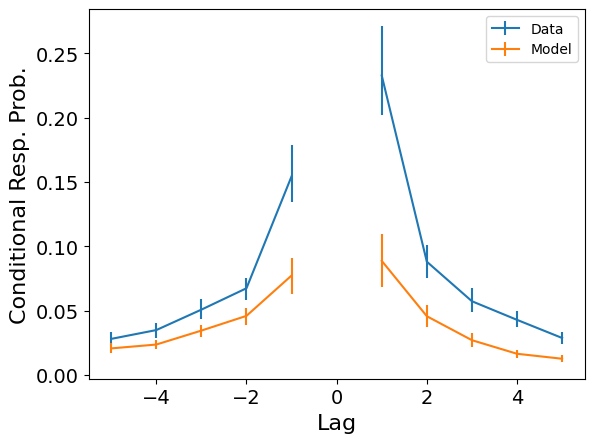

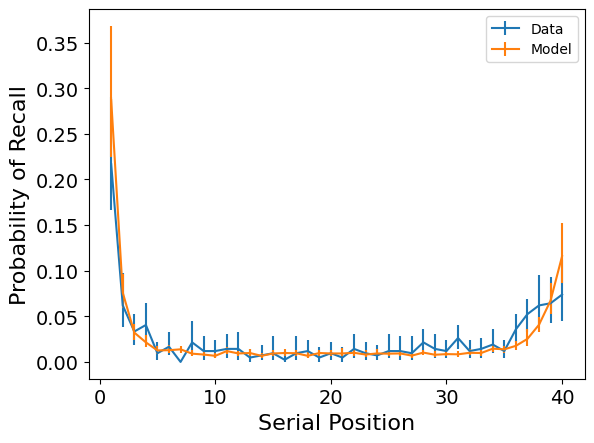

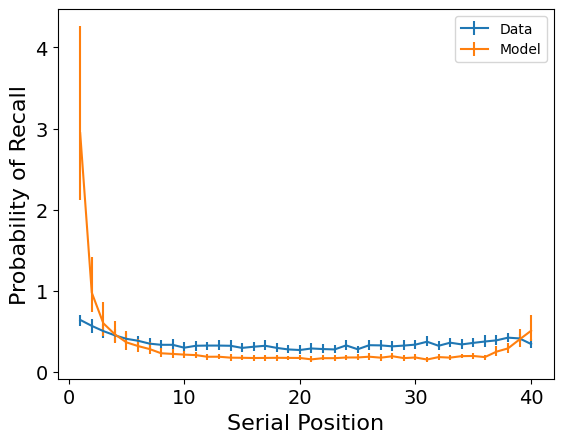

In [4]:
trial_query = "data['list_type'] == 1"

datasets = [data, result]
trial_masks = [ generate_trial_mask(data, trial_query),  generate_trial_mask(result, trial_query)]

for analysis_name in analyses:
    analysis = analyses[analysis_name]

    axis = analysis(datasets, trial_masks, labels=['Data', 'Model'], contrast_name=model_name.replace('_', ' '))
    
    axis.legend(title=None)
    axis.tick_params(labelsize=14)
    axis.set_xlabel(axis.get_xlabel(), fontsize=16)
    axis.set_ylabel(axis.get_ylabel(), fontsize=16)

    plt.show()

## Repetition Contiguity

In [4]:
from jaxcmr.analyses import recall_by_all_study_positions

from numba import njit
import numpy as np

@njit(nogil=True)
def repetition_contiguity(trials, presentations, lag_threshold = 4, max_repeats = 2):
    
    list_length = len(presentations[0])
    lag_range = list_length - 1
    total_actual_lags = np.zeros((max_repeats, lag_range * 2 + 1)) # extended dimension to split by pres positions
    total_possible_lags = np.zeros((max_repeats, lag_range * 2 + 1))
    terminus = np.sum(trials != 0, axis=1) # number of recalls per trial
    recall_by_study_position = recall_by_all_study_positions(trials, presentations, max_repeats)
    
    for trial_index in range(len(trials)):
        previous_item = 0
        item_count = np.max(presentations[trial_index]) + 1
        possible_items = np.arange(item_count) # initial pool of possible recalls, 1-indexed
        possible_positions = np.zeros((item_count, max_repeats), dtype=np.int32)
        
        # we track possible positions using presentations and alt_presentations
        for item in range(item_count):
            pos = np.nonzero(presentations[trial_index] == item)[0] + 1
            possible_positions[item, :len(pos)] = pos
            
        for recall_index in range(terminus[trial_index]):

            current_item = presentations[trial_index][trials[trial_index, recall_index]-1]
            
            # track possible and actual lags; 
            # focus only on transitions from items with > 1 study positions
            # and only when those multiple study positions have lag over lag
            if recall_index > 0 and np.count_nonzero(
                possible_positions[previous_item]) > 1 and (
                possible_positions[previous_item][1] - possible_positions[previous_item][0] >= lag_threshold):
                #possible_positions[previous_item][1] - possible_positions[previous_item][0] >= lag_threshold) and (
                #possible_positions[previous_item][2] - possible_positions[previous_item][1] >= 6):
                
                # item indices don't help track lags anymore
                # so more complex calculation needed to identify possible lags given previous item
                current_index = np.nonzero(possible_items==current_item)[0]

                index = 0
                for x in range(len(recall_by_study_position)):
                    for y in range(len(recall_by_study_position)):
                        if possible_positions[previous_item, y] > 0:
                        
                            possible_lags = possible_positions[
                                possible_items, x] - possible_positions[previous_item, y]
                            
                            # if tracked position is 0, then we don't actually want to count it in our lags
                            possible_lags[possible_positions[possible_items, x] == 0] = 0
                            
                            # we track actual lag at each iteration
                            actual_lag = possible_lags[current_index] + lag_range
                            total_actual_lags[y][actual_lag] += 1

                            # we track possible lag at each iteration
                            possible_lags += lag_range
                            total_possible_lags[y][possible_lags] += 1
                        
                        index += 1

            # update pool to exclude recalled item (updated to still identify 1-indexed item)
            previous_item = current_item
            possible_items = possible_items[possible_items != previous_item]

                                
    # small correction to avoid nans and commit to excluding multiply-tracked single presentations 
    total_actual_lags[:, lag_range] = 0
    for i in range(max_repeats):
        total_possible_lags[i][total_actual_lags[i]==0] += 1
    
    return total_actual_lags/total_possible_lags

In [5]:
repetition_contiguity(data['recalls'], data['pres_itemnos'], lag_threshold = 4, max_repeats = 2)

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.06451613, 0.07407407, 0.04807692, 0.03680982, 0.02202643,
        0.04467354, 0.02150538, 0.02901786, 0.03374778, 0.04133545,
        0.04252401, 0.03443878, 0.0300578 , 0.02934783, 0.04426559,
        0.02748815, 0.03318777, 0.03505843, 0.02898551, 0.03036876,
        0.03651685, 0.03472669, 0.03068253, 0.03725606, 0.05022573,
        0.04      , 0.05178664, 0.04913151, 0.06047412, 0.06441149,
        0.06403941, 0.08726003, 0.10261737, 0.17977528, 0.        ,
        0.27345501, 0.16226535, 0.14427701, 0.14376489, 0.14823091,
        0.14851126, 0.13366513, 0.11794139, 0.11634349, 0.11251182,
        0.08024104, 0.05564812, 0.05587734, 0.05014327, 0.03963303,
        0.03634277, 0.02903739, 0.03486924, 0.03257608, 0.03199639,
        0.02419355, 0.02871287, 0.02379693, 0.02701182, 0.02339532,
        0.0214511 , 0.02905405, 0.02325581, 0.0226209 , 0.02201524,
        0.01846722, 0.02689243, 0.02254791, 0.01

In [6]:
repetition_contiguity(result['recalls'], result['pres_itemnos'], lag_threshold = 4, max_repeats = 2)

array([[0.        , 0.        , 0.        , 0.        , 0.08333333,
        0.11428571, 0.08064516, 0.05154639, 0.03759398, 0.03703704,
        0.04819277, 0.03144654, 0.03667482, 0.03891051, 0.03225806,
        0.02583587, 0.03830911, 0.03936039, 0.03455964, 0.03108808,
        0.03173077, 0.04035088, 0.02962963, 0.04260263, 0.03584492,
        0.03469813, 0.04834606, 0.04520124, 0.04302397, 0.05220884,
        0.06089385, 0.06303879, 0.06474456, 0.06774669, 0.06569686,
        0.08695652, 0.10388477, 0.10229645, 0.15861514, 0.        ,
        0.19242902, 0.14245515, 0.1285055 , 0.12594908, 0.15201005,
        0.14841849, 0.13190803, 0.12751128, 0.11370787, 0.12249362,
        0.08707025, 0.0780303 , 0.0656963 , 0.07058824, 0.05311973,
        0.05098039, 0.04478976, 0.04370797, 0.03920596, 0.03954802,
        0.03754081, 0.03159104, 0.02691388, 0.03079824, 0.0203252 ,
        0.02972399, 0.02277904, 0.02417405, 0.01297578, 0.02234637,
        0.03115578, 0.02572707, 0.02114428, 0.01